# Data Cleaning

## Load needed Libraries and modules

In [1]:
# import Libs
import pandas as pd
import datetime as dt
import pytz
import os
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# import modules
from datetime import datetime, timezone
from datetime import date, time
from math import trunc
from dateutil.parser import parse

## Loading the Data needed into Dataframes

### Load the csv files

In [2]:
mb_src_prices = pd.read_csv("mb_tickerdf12302025 2025-12-30 17-24-53-423976.csv", index_col=0)
mb_src_options = pd.read_csv("mb_all_options_data12302025 2025-12-30 17-24-55-033746.csv", index_col=0)
mb_src_ir = pd.read_csv("mb_US_T_12292025 2025-12-30 17-06-29-282207.csv", index_col=0)

# Parsing the dates in the index and convert them to date only (without time or timezone info)
mb_src_prices.index = mb_src_prices.index.map(lambda x: parse(x).date())

print(mb_src_prices)
print(mb_src_options)
print(mb_src_ir)

                  Open        High         Low       Close     Volume  \
2020-12-31  130.520487  131.162969  128.223139  129.167389   99116600   
2021-01-04  129.975370  130.062977  123.394829  125.974480  143301900   
2021-01-05  125.468261  128.242606  125.020466  127.531975   97664900   
2021-01-06  124.329352  127.570950  123.024922  123.239082  155088000   
2021-01-07  124.952354  128.135547  124.465627  127.444389  109578200   
...                ...         ...         ...         ...        ...   
2025-12-23  270.839996  272.500000  269.559998  272.359985   29642000   
2025-12-24  272.339996  275.429993  272.200012  273.809998   17910600   
2025-12-26  274.160004  275.369995  272.859985  273.399994   21521800   
2025-12-29  272.690002  274.359985  272.350006  273.760010   23715200   
2025-12-30  272.834991  274.079987  272.279999  273.079987   22090083   

            Dividends  Stock Splits  
2020-12-31        0.0           0.0  
2021-01-04        0.0           0.0  
2021-01-0

### Prices

In [3]:
# Copy Sources Data DataFrame
mb_prices = mb_src_prices.copy()

# Drop the unwanted columns from the DataFrame
mb_prices = mb_prices.drop(['Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock Splits'], axis=1)

# Format the index to display only the date in 'yyyy-mm-dd' format
mb_prices.index = pd.to_datetime(mb_prices.index).strftime('%Y-%m-%d')

# Rename the 'Close' column to 'AAPL'
mb_prices = mb_prices.rename(columns={'Close': 'AAPL'})

# Print the updated DataFrame with formatted index
mb_prices

,AAPL
2020-12-31,129.167389
2021-01-04,125.974480
2021-01-05,127.531975
2021-01-06,123.239082
2021-01-07,127.444389
...,...
2025-12-23,272.359985
2025-12-24,273.809998
2025-12-26,273.399994
2025-12-29,273.760010


### Prices table enriched

In [4]:
# Calculating the log returns
mb_prices['Log Returns'] = np.log(mb_prices['AAPL'] / mb_prices['AAPL'].shift(1))

# Number of trading days in a year
trading_days = 252

# Calculating the 1-year rolling volatility
mb_prices['1y Historical Volatility'] = mb_prices['Log Returns'].rolling(window=trading_days).std() * np.sqrt(trading_days)

# Drop the 'Log Returns' column as we don't need it anymore
mb_prices = mb_prices.drop(columns=['Log Returns'])

mb_prices

,AAPL,1y Historical Volatility
2020-12-31,129.167389,NaN
2021-01-04,125.974480,NaN
2021-01-05,127.531975,NaN
2021-01-06,123.239082,NaN
2021-01-07,127.444389,NaN
...,...,...
2025-12-23,272.359985,0.322162
2025-12-24,273.809998,0.321678
2025-12-26,273.399994,0.321671
2025-12-29,273.760010,0.321479


In [5]:
mb_prices.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1255 entries, 2020-12-31 to 2025-12-30
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AAPL                      1255 non-null   float64
 1   1y Historical Volatility  1003 non-null   float64
dtypes: float64(2)
memory usage: 29.4+ KB


In [6]:
mb_prices.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
AAPL,1255.0,179.427557,40.032726,113.440163,146.065323,171.671036,210.593315,286.190002
1y Historical Volatility,1003.0,0.275546,0.051568,0.188945,0.225562,0.284434,0.321228,0.358606


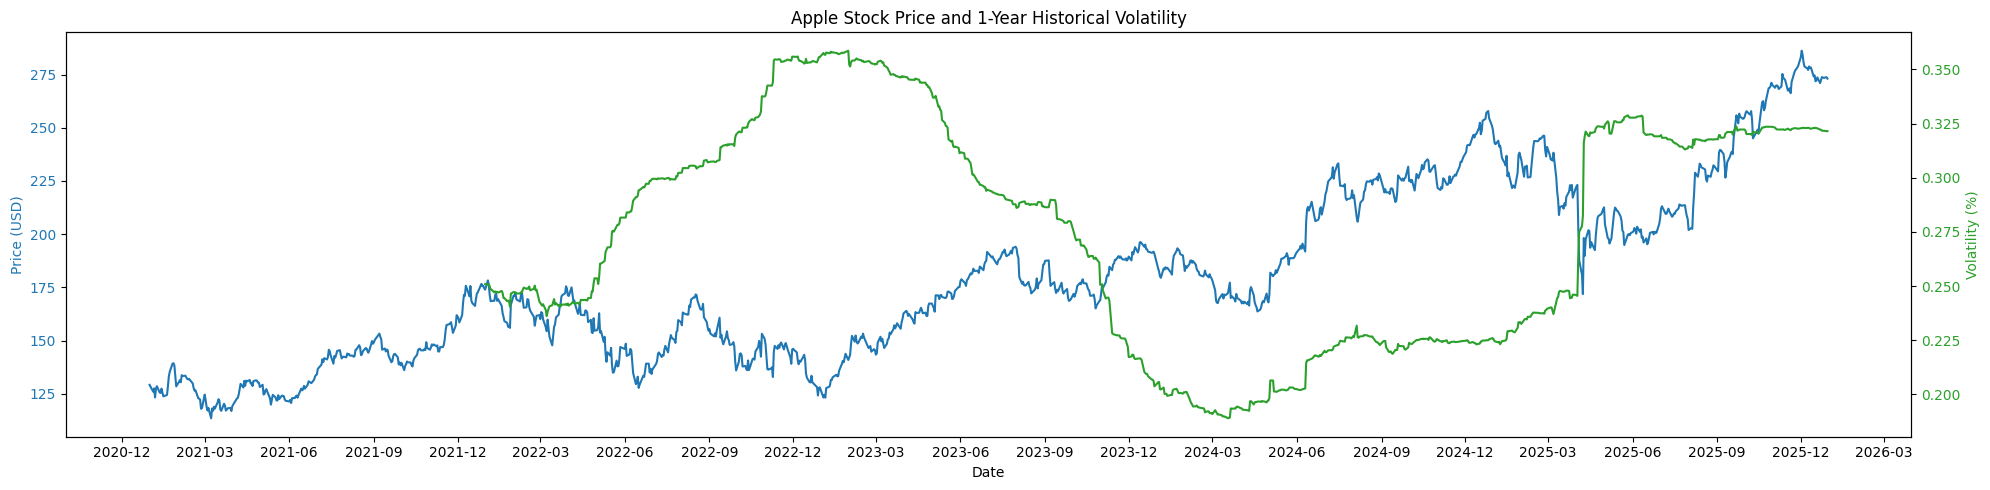

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Ensure the index is in datetime format
mb_prices.index = pd.to_datetime(mb_prices.index)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(20, 5))

# Create secondary y-axis
ax2 = ax1.twinx()

# ---- Price series (primary axis) ----
color1 = 'tab:blue'
ax1.plot(
    mb_prices.index,
    mb_prices['AAPL'],
    label='AAPL Stock Price',
    color=color1
)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# ---- Volatility series (secondary axis) ----
color2 = 'tab:green'
ax2.plot(
    mb_prices.index,
    mb_prices['1y Historical Volatility'],
    label='1Y Historical Volatility',
    color=color2
)
ax2.set_ylabel('Volatility (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# ---- Title ----
plt.title('Apple Stock Price and 1-Year Historical Volatility')

# ---- Proper date handling (key fix) ----
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # every 3 months
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

# ---- Layout ----
fig.tight_layout()
plt.show()


### Options details

In [8]:
# Copy Sources Data DataFrame
mb_options = mb_src_options.copy()

# Drop the unwanted columns from the DataFrame
mb_options = mb_options.drop(['bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'contractSize'], axis=1)

# Print the updated DataFrame with formatted index
mb_options

,contractSymbol,lastTradeDate,strike,lastPrice,impliedVolatility,inTheMoney,currency,OptionType,expirationDate,time_to_expiration
0,AAPL260102C00120000,2025-12-29 14:52:51+00:00,120.0,153.88,3.335939,True,USD,Call,2026-01-02,3
1,AAPL260102C00135000,2025-12-08 14:31:30+00:00,135.0,144.95,2.843753,True,USD,Call,2026-01-02,3
2,AAPL260102C00145000,2025-11-19 16:06:45+00:00,145.0,126.05,2.621097,True,USD,Call,2026-01-02,3
3,AAPL260102C00150000,2025-12-29 20:59:30+00:00,150.0,123.83,2.492191,True,USD,Call,2026-01-02,3
4,AAPL260102C00155000,2025-12-29 20:59:30+00:00,155.0,118.90,2.369145,True,USD,Call,2026-01-02,3
...,...,...,...,...,...,...,...,...,...,...
2317,AAPL280317P00330000,2025-12-26 19:28:14+00:00,330.0,65.85,0.174355,True,USD,Put,2028-03-17,808
2318,AAPL280317P00340000,2025-12-30 17:32:03+00:00,340.0,74.42,0.165444,True,USD,Put,2028-03-17,808
2319,AAPL280317P00350000,2025-12-30 17:34:24+00:00,350.0,81.91,0.161980,True,USD,Put,2028-03-17,808
2320,AAPL280317P00380000,2025-12-22 14:30:05+00:00,380.0,107.46,0.140023,True,USD,Put,2028-03-17,808


### Implied Volatilities

In [9]:
# Take a Copy of the Options DataFrame
df = mb_options.copy()

# Filter for call options and create a pivot table
mb_call_options = df[df['OptionType'] == 'Call']
mb_call_iv_matrix = mb_call_options.pivot(index='time_to_expiration', columns='strike', values='impliedVolatility')

# Filter for put options and create a pivot table
mb_put_options = df[df['OptionType'] == 'Put']
mb_put_iv_matrix = mb_put_options.pivot(index='time_to_expiration', columns='strike', values='impliedVolatility')

# Fill NaN values with zero (optional)
mb_call_iv_matrix = mb_call_iv_matrix.fillna(0)
mb_put_iv_matrix = mb_put_iv_matrix.fillna(0)

# Sort the index and columns (optional)
mb_call_iv_matrix.sort_index(axis=0, inplace=True)
mb_call_iv_matrix.sort_index(axis=1, inplace=True)

mb_put_iv_matrix.sort_index(axis=0, inplace=True)
mb_put_iv_matrix.sort_index(axis=1, inplace=True)

In [10]:
print("\nCall implied volatility matrix:")
mb_call_iv_matrix


Call implied volatility matrix:


strike,5.0,10.0,15.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,...,460.0,470.0,480.0,490.0,500.0,510.0,520.0,530.0,540.0,550.0
time_to_expiration,,,,,,,,,,,,,,,,,,,,,
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,9.960941,5.375003,4.875004,4.367192,3.984375,3.789063,5.280277,6.174319,4.638676,2.902346,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
24,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
38,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
52,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [11]:
print("\nPut implied volatility matrix:")
mb_put_iv_matrix


Put implied volatility matrix:


strike,5.0,10.0,15.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,...,420.0,430.0,435.0,440.0,450.0,460.0,480.0,500.0,530.0,550.0
time_to_expiration,,,,,,,,,,,,,,,,,,,,,
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
17,5.500003,4.687504,5.203128,3.500001,3.187502,0.500005,2.875003,3.078127,2.968753,2.250004,...,0.718753,0.710940,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
24,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
38,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
52,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.738284,0.000000,0.000000,0.00000,0.000000,0.000000
80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.506353,0.524541,0.000000,0.000000,0.00000,0.000000,0.000000


In [12]:
# Select first 5 and last 5 columns of Call implied volatility matrix
mb_call_selected = pd.concat([mb_call_iv_matrix.iloc[:, :5], mb_call_iv_matrix.iloc[:, -5:]], axis=1)
print("\nSelected columns from Call implied volatility matrix:")
mb_call_selected


Selected columns from Call implied volatility matrix:


strike,5.0,10.0,15.0,20.0,25.0,510.0,520.0,530.0,540.0,550.0
time_to_expiration,,,,,,,,,,
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,9.960941,5.375003,4.875004,4.367192,3.984375,0.000000,0.000000,0.000000,0.000000,0.000000
24,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
38,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
52,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
# Select first 5 and last 5 columns of Put implied volatility matrix
mb_put_selected = pd.concat([mb_put_iv_matrix.iloc[:, :5], mb_put_iv_matrix.iloc[:, -5:]], axis=1)
print("\nSelected columns from Put implied volatility matrix:")
mb_put_selected


Selected columns from Put implied volatility matrix:


strike,5.0,10.0,15.0,20.0,25.0,460.0,480.0,500.0,530.0,550.0
time_to_expiration,,,,,,,,,,
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
17,5.500003,4.687504,5.203128,3.500001,3.187502,0.000000,0.000000,0.00000,0.000000,0.000000
24,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
38,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
52,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
80,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


### The clean implied volatility matrix

In [14]:
'''
Let's now combine the 2 matrices in to one mb_iv
The rule here is to take the average of the 2 when the vol is not zero or not n/a
'''

# First replace zeros with NaN in both matrices
mb_call_iv_matrix.replace(0, np.nan, inplace=True)
mb_put_iv_matrix.replace(0, np.nan, inplace=True)

# Define a custom function to calculate average if neither is zero or NaN
def mb_custom_combine(ser1, ser2):
    ser1_valid = ser1.notna()
    ser2_valid = ser2.notna()
    both_valid = ser1_valid & ser2_valid
    return pd.Series(np.where(both_valid, (ser1 + ser2)/2, np.where(ser1_valid, ser1, ser2)), index=ser1.index)

# Apply the custom function column-wise
mb_iv = mb_call_iv_matrix.combine(mb_put_iv_matrix, mb_custom_combine)

print("\nCombined implied volatility matrix:")
mb_iv


Combined implied volatility matrix:


strike,5.0,10.0,15.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,...,460.0,470.0,480.0,490.0,500.0,510.0,520.0,530.0,540.0,550.0
time_to_expiration,,,,,,,,,,,,,,,,,,,,,
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,7.730472,5.031254,5.039066,3.933597,3.585939,2.144534,4.077640,4.626223,3.803714,2.576175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
mb_iv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 3 to 808
Columns: 113 entries, 5.0 to 550.0
dtypes: float64(113)
memory usage: 17.8 KB


In [16]:
# Display up to 500 rows and 500 columns
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
mb_iv.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
strike,,,,,,,,
5.0,8.0,2.587680,2.121268,1.351566,1.559878,1.794436,2.397953,7.730472
10.0,7.0,1.902277,1.409886,0.960943,1.242069,1.330081,1.754762,5.031254
15.0,8.0,1.624073,1.427050,0.627448,0.948246,1.155826,1.476626,5.039066
20.0,7.0,1.533154,1.118876,0.744147,0.875612,1.050786,1.626163,3.933597
25.0,8.0,1.226093,1.022475,0.492193,0.636115,0.838381,1.391817,3.585939
30.0,8.0,0.926548,0.592172,0.454107,0.557866,0.718632,1.000856,2.144534
35.0,7.0,1.334572,1.251787,0.421881,0.695895,0.905277,1.272708,4.077640
40.0,6.0,1.402856,1.611476,0.411383,0.568885,0.753726,1.212039,4.626223
45.0,6.0,1.305220,1.257166,0.347663,0.696719,0.944095,1.119145,3.803714


In [17]:
# To reset pandas' display options to their defaults
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [18]:
# Select first 5 and last 5 columns of implied volatility matrix
mb_iv_selected = pd.concat([mb_iv.iloc[:, :5], mb_iv.iloc[:, -5:]], axis=1)
print("\nSelected columns from Put implied volatility matrix:")
mb_iv_selected


Selected columns from Put implied volatility matrix:


strike,5.0,10.0,15.0,20.0,25.0,510.0,520.0,530.0,540.0,550.0
time_to_expiration,,,,,,,,,,
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,7.730472,5.031254,5.039066,3.933597,3.585939,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Interest Rates

In [19]:
# Copy Sources Data DataFrame
mb_interest_rates = mb_src_ir.copy()

# Print the updated DataFrame with formatted index
mb_interest_rates

,US_Treasury_Pillar,Yield
0,1M,3.69
1,3M,3.68
2,6M,3.59
3,1Y,3.48
4,2Y,3.45
5,3Y,3.51
6,5Y,3.67
7,7Y,3.88
8,10Y,4.12
9,20Y,4.75


## Preparing Data for Model Development and Testing

### Preparing the underlying price

In [20]:
mb_price_on_date = mb_prices.loc['2025-12-30', 'AAPL']
print(f"The price of AAPL on 2025-12-30 was {mb_price_on_date}")

The price of AAPL on 2025-12-30 was 273.0799865722656


### Preparing the options static data

In [21]:
# First, make a copy of your DataFrame
mb_options_copy = mb_options.copy()

# Add new column 'OptionStyle' and set all its values to 'American'
mb_options_copy['OptionStyle'] = 'American'

mb_options_copy

,contractSymbol,lastTradeDate,strike,lastPrice,impliedVolatility,inTheMoney,currency,OptionType,expirationDate,time_to_expiration,OptionStyle
0,AAPL260102C00120000,2025-12-29 14:52:51+00:00,120.0,153.88,3.335939,True,USD,Call,2026-01-02,3,American
1,AAPL260102C00135000,2025-12-08 14:31:30+00:00,135.0,144.95,2.843753,True,USD,Call,2026-01-02,3,American
2,AAPL260102C00145000,2025-11-19 16:06:45+00:00,145.0,126.05,2.621097,True,USD,Call,2026-01-02,3,American
3,AAPL260102C00150000,2025-12-29 20:59:30+00:00,150.0,123.83,2.492191,True,USD,Call,2026-01-02,3,American
4,AAPL260102C00155000,2025-12-29 20:59:30+00:00,155.0,118.90,2.369145,True,USD,Call,2026-01-02,3,American
...,...,...,...,...,...,...,...,...,...,...,...
2317,AAPL280317P00330000,2025-12-26 19:28:14+00:00,330.0,65.85,0.174355,True,USD,Put,2028-03-17,808,American
2318,AAPL280317P00340000,2025-12-30 17:32:03+00:00,340.0,74.42,0.165444,True,USD,Put,2028-03-17,808,American
2319,AAPL280317P00350000,2025-12-30 17:34:24+00:00,350.0,81.91,0.161980,True,USD,Put,2028-03-17,808,American
2320,AAPL280317P00380000,2025-12-22 14:30:05+00:00,380.0,107.46,0.140023,True,USD,Put,2028-03-17,808,American


In [22]:
mb_options_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2322 entries, 0 to 2321
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   contractSymbol      2322 non-null   object 
 1   lastTradeDate       2322 non-null   object 
 2   strike              2322 non-null   float64
 3   lastPrice           2322 non-null   float64
 4   impliedVolatility   2322 non-null   float64
 5   inTheMoney          2322 non-null   bool   
 6   currency            2322 non-null   object 
 7   OptionType          2322 non-null   object 
 8   expirationDate      2322 non-null   object 
 9   time_to_expiration  2322 non-null   int64  
 10  OptionStyle         2322 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(6)
memory usage: 201.8+ KB


In [23]:
mb_options_copy.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
strike,2322.0,234.918174,113.381492,5.00000,155.000000,235.000000,310.000000,550.000000
lastPrice,2322.0,46.212976,64.061545,0.01000,0.550000,12.050000,72.942500,275.800000
impliedVolatility,2322.0,0.500941,0.551448,0.00001,0.249161,0.330756,0.548222,9.960941
time_to_expiration,2322.0,269.082257,256.949376,3.00000,52.000000,170.000000,381.000000,808.000000


In [24]:
print(mb_options_copy.columns)

Index(['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice',
       'impliedVolatility', 'inTheMoney', 'currency', 'OptionType',
       'expirationDate', 'time_to_expiration', 'OptionStyle'],
      dtype='object')


In [25]:
# The columns we are interested in.
mb_columns_to_check = ['strike', 'inTheMoney', 'currency', 'OptionType', 'time_to_expiration', 'OptionStyle']

for column in mb_columns_to_check:
    print(f"{column}: {mb_options_copy[column].unique()}")

strike: [120.  135.  145.  150.  155.  160.  165.  170.  175.  180.  185.  190.
 195.  200.  205.  210.  215.  220.  225.  230.  232.5 235.  237.5 240.
 245.  247.5 250.  252.5 255.  257.5 260.  262.5 265.  267.5 270.  272.5
 275.  277.5 280.  282.5 285.  287.5 290.  292.5 295.  297.5 300.  302.5
 305.  310.  315.  320.  325.  330.  335.  340.  345.  350.  355.  360.
 400.  110.  125.  130.  140.  370.  375.  380.  385.  390.    5.   10.
  15.   20.   25.   30.   35.   40.   45.   50.   55.   60.   65.   70.
  75.   80.   85.   90.   95.  100.  105.  115.  410.  420.  430.  440.
 450.  365.  460.  470.  480.  490.  500.  510.  520.  530.  540.  550.
 395.  405.  415.  425.  435. ]
inTheMoney: [ True False]
currency: ['USD']
OptionType: ['Call' 'Put']
time_to_expiration: [  3  10  17  24  31  38  52  80 108 136 170 199 234 262 353 381 534 717
 752 808]
OptionStyle: ['American']


In [26]:
# Display up to 500 rows and 500 columns
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

mb_pivot_table1 = mb_options_copy.pivot_table(index='strike', 
                                          columns='OptionType', 
                                          values='contractSymbol', 
                                          aggfunc='count')

mb_pivot_table1

OptionType,Call,Put
strike,,
5.0,8.0,8.0
10.0,6.0,7.0
15.0,8.0,7.0
20.0,6.0,7.0
25.0,5.0,8.0
30.0,6.0,7.0
35.0,6.0,7.0
40.0,6.0,6.0
45.0,5.0,6.0


In [27]:
# Display up to 500 rows and 500 columns
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

mb_pivot_table2 = mb_options_copy.pivot_table(index='time_to_expiration', 
                                          columns='strike', 
                                          values='contractSymbol', 
                                          aggfunc='count')

mb_pivot_table2

strike,5.0,10.0,15.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0,75.0,80.0,85.0,90.0,95.0,100.0,105.0,110.0,115.0,120.0,125.0,130.0,135.0,140.0,145.0,150.0,155.0,160.0,165.0,170.0,175.0,180.0,185.0,190.0,195.0,200.0,205.0,210.0,215.0,220.0,225.0,230.0,232.5,235.0,237.5,240.0,245.0,247.5,250.0,252.5,255.0,257.5,260.0,262.5,265.0,267.5,270.0,272.5,275.0,277.5,280.0,282.5,285.0,287.5,290.0,292.5,295.0,297.5,300.0,302.5,305.0,310.0,315.0,320.0,325.0,330.0,335.0,340.0,345.0,350.0,355.0,360.0,365.0,370.0,375.0,380.0,385.0,390.0,395.0,400.0,405.0,410.0,415.0,420.0,425.0,430.0,435.0,440.0,450.0,460.0,470.0,480.0,490.0,500.0,510.0,520.0,530.0,540.0,550.0
time_to_expiration,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,2.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,NaN,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,1.0,2.0,NaN,1.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,2.0,2.0,1.0,NaN,2.0,NaN,2.0,1.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1.0,NaN,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,

In [28]:
# To reset pandas' display options to their defaults
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [29]:
mb_options_sorted = mb_options_copy.sort_values(by='lastTradeDate')
mb_options_sorted.head(100)

,contractSymbol,lastTradeDate,strike,lastPrice,impliedVolatility,inTheMoney,currency,OptionType,expirationDate,time_to_expiration,OptionStyle
1800,AAPL270115P00410000,2024-12-10 14:30:05+00:00,410.0,162.74,0.714740,True,USD,Put,2027-01-15,381,American
1802,AAPL270115P00430000,2024-12-16 05:02:15+00:00,430.0,203.30,0.577961,True,USD,Put,2027-01-15,381,American
1668,AAPL261218P00440000,2025-01-03 15:21:54+00:00,440.0,197.30,0.000010,True,USD,Put,2026-12-18,353,American
1179,AAPL260618P00370000,2025-01-06 15:17:33+00:00,370.0,124.00,0.000010,True,USD,Put,2026-06-18,170,American
1935,AAPL270617P00430000,2025-02-12 14:45:18+00:00,430.0,198.33,0.759249,True,USD,Put,2027-06-17,534,American
...,...,...,...,...,...,...,...,...,...,...,...
312,AAPL260116P00060000,2025-11-04 16:26:37+00:00,60.0,0.01,2.429691,False,USD,Put,2026-01-16,17,American
788,AAPL260417C00140000,2025-11-04 16:47:01+00:00,140.0,133.61,0.741702,True,USD,Call,2026-04-17,108,American
1667,AAPL261218P00410000,2025-11-04 17:16:25+00:00,410.0,140.20,0.256660,True,USD,Put,2026-12-18,353,American
1665,AAPL261218P00390000,2025-11-04 17:16:25+00:00,390.0,120.22,0.232552,True,USD,Put,2026-12-18,353,American


In [30]:
mb_unique_strikes_first = mb_options_sorted['strike'].head(100).unique()
mb_unique_strikes_first.sort()
print(mb_unique_strikes_first)

[ 10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.  70.  75.
  80.  85.  90.  95. 110. 115. 125. 130. 140. 145. 340. 350. 360. 370.
 380. 390. 400. 410. 420. 430. 435. 440. 450. 500.]


In [31]:
mb_options_sorted = mb_options_copy.sort_values(by='lastTradeDate', ascending=False)
mb_options_sorted.head(100)

,contractSymbol,lastTradeDate,strike,lastPrice,impliedVolatility,inTheMoney,currency,OptionType,expirationDate,time_to_expiration,OptionStyle
96,AAPL260102P00275000,2025-12-30 20:59:59+00:00,275.0,2.49,0.116708,True,USD,Put,2026-01-02,3,American
402,AAPL260123C00270000,2025-12-30 20:59:58+00:00,270.0,7.16,0.194832,True,USD,Call,2026-01-23,24,American
94,AAPL260102P00270000,2025-12-30 20:59:57+00:00,270.0,0.39,0.127694,False,USD,Put,2026-01-02,3,American
36,AAPL260102C00275000,2025-12-30 20:59:54+00:00,275.0,0.65,0.124887,False,USD,Call,2026-01-02,3,American
95,AAPL260102P00272500,2025-12-30 20:59:53+00:00,272.5,1.08,0.118539,False,USD,Put,2026-01-02,3,American
...,...,...,...,...,...,...,...,...,...,...,...
655,AAPL260220P00275000,2025-12-30 20:57:38+00:00,275.0,9.30,0.203072,True,USD,Put,2026-02-20,52,American
400,AAPL260123C00260000,2025-12-30 20:57:27+00:00,260.0,15.05,0.239510,True,USD,Call,2026-01-23,24,American
1151,AAPL260618P00205000,2025-12-30 20:57:26+00:00,205.0,1.87,0.304206,False,USD,Put,2026-06-18,170,American
708,AAPL260320C00280000,2025-12-30 20:57:22+00:00,280.0,9.02,0.234810,False,USD,Call,2026-03-20,80,American


### Preparing the volatilities grid

In [32]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
mb_iv

strike,5.0,10.0,15.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0,75.0,80.0,85.0,90.0,95.0,100.0,105.0,110.0,115.0,120.0,125.0,130.0,135.0,140.0,145.0,150.0,155.0,160.0,165.0,170.0,175.0,180.0,185.0,190.0,195.0,200.0,205.0,210.0,215.0,220.0,225.0,230.0,232.5,235.0,237.5,240.0,245.0,247.5,250.0,252.5,255.0,257.5,260.0,262.5,265.0,267.5,270.0,272.5,275.0,277.5,280.0,282.5,285.0,287.5,290.0,292.5,295.0,297.5,300.0,302.5,305.0,310.0,315.0,320.0,325.0,330.0,335.0,340.0,345.0,350.0,355.0,360.0,365.0,370.0,375.0,380.0,385.0,390.0,395.0,400.0,405.0,410.0,415.0,420.0,425.0,430.0,435.0,440.0,450.0,460.0,470.0,480.0,490.0,500.0,510.0,520.0,530.0,540.0,550.0
time_to_expiration,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.625003,NaN,2.855472,2.250004,2.125005,2.437504,1.937500,2.216799,2.121096,2.012698,2.248051,2.130864,1.843751,1.777345,1.552737,1.720705,1.487307,1.391605,1.249027,1.211918,1.072268,0.988772,0.751956,0.785647,0.785161,0.79883,0.624027,0.748294,0.540532,0.513188,0.590214,0.467046,0.404303,0.411627,0.407232,0.278083,0.250740,0.197030,0.177987,0.137887,0.125192,0.120797,0.136361,0.158089,0.196541,0.243050,0.341926,0.325934,0.391608,0.402838,0.496587,0.498296,0.359381,0.603642,0.664798,0.754031,0.500005,0.546880,0.578129,0.625004,1.004398,1.068362,1.118411,0.781252,1.316898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.093755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.605471,1.570315,1.451175,1.332523,1.093755,1.145024,1.068364,0.750003,1.096194,1.030278,0.971194,0.751956,0.780764,0.735110,0.672855,0.629154,0.521245,0.531865,NaN,0.428473,NaN,0.502446,0.447149,0.388678,0.307502,0.352423,0.298713,0.279731,0.227303,0.206673,0.192269,0.179513,0.171944,0.163644,0.157662,0.152657,0.149484,0.155648,0.165047,0.194344,0.224495,0.177743,0.250618,0.207039,0.304084,NaN,0.383673,0.435675,0.456060,0.553715,0.371100,0.642948,0.398444,0.557622,0.585942,0.476568,NaN,NaN,NaN,0.725589,0.748049,0.775393,1.198002,1.214115,NaN,0.873048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,7.730472,5.031254,5.039066,3.933597,3.585939,2.144534,4.077640,4.626223,3.803714,2.576175,2.881839,2.599613,2.265627,2.214848,2.064456,2.024417,1.953128,1.806644,1.922855,1.648439,1.615236,1.679689,1.492190,1.435550,1.407718,1.263676,1.259281,1.208988,1.140627,1.084963,1.048099,0.952640,0.899174,0.859379,0.810060,0.768069,0.761721,0.719241,0.686527,0.623051,0.606449,0.561528,0.505864,0.441656,0.440801,0.414312,NaN,0.403815,NaN,0.340949,0.325446,0.352485,0.270271,0.255501,0.241707,0.250984,0.217781,0.206063,0.197274,0.189003,0.181344,0.175606,0.170052,0.164742,0.159676,0.157296,0.153573,0.155282,0.161874,0.173714,0.215828,NaN,0.240486,NaN,0.267708,0.292732,0.360968,0.315681,0.423224,0.437628,0.539433,0.492864,NaN,0.508794,NaN,0.547612,0.676273,0.654667,NaN,0.515630,NaN,0.728762,NaN,0.754397,NaN,0.794804,NaN,0.706058,NaN,0.747073,NaN,0.818361,0.671878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.186528,0.919923,NaN,NaN,NaN,NaN,0.716800,NaN,0.638675,0.598637,0.563481,0.588627,0.433599,0.475103,0.450201,0.507939,0.447820,0.391608,NaN,0.375983,NaN,0.374457,0.329841,NaN,0.296089,NaN,0.251778,NaN,0.215035,NaN,0.194191,NaN,0.181801,NaN,0.170052,NaN,0.162484,NaN,0.156808,NaN,0.189095,NaN,0.228218,NaN,0.249275,NaN,0.275032,0.297126,0.222664,0.343146,0.264656,0.356452,0.387701,0.339850,NaN,0.452642,0.474126,0.489263,0.509771,NaN,NaN,NaN,NaN,NaN,NaN,0.583012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [33]:
# Take a copy of mb_iv
mb_iv_std = mb_iv.copy()

# Filter rows based on time_to_expiration
mb_desired_tenors = [3, 10, 17, 31, 80, 108, 136, 170, 199, 353, 381, 534, 717, 808]
mb_iv_std = mb_iv_std[mb_iv_std.index.isin(mb_desired_tenors)]

# Specify the desired strike values (21 Stike points)
mb_desired_strikes = [135, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 440]

# Filter columns based on desired_strikes
mb_iv_std = mb_iv_std[mb_desired_strikes]

# Display
mb_iv_std

strike,135.0,235.0,240.0,245.0,250.0,255.0,260.0,265.0,270.0,275.0,280.0,285.0,290.0,295.0,300.0,305.0,310.0,315.0,320.0,325.0,330.0,335.0,340.0,440.0
time_to_expiration,,,,,,,,,,,,,,,,,,,,,,,,
3,2.437504,0.624027,0.540532,0.513188,0.467046,0.411627,0.278083,0.197030,0.137887,0.120797,0.158089,0.243050,0.325934,0.402838,0.498296,0.603642,0.664798,0.754031,0.500005,0.546880,0.578129,0.625004,1.004398,NaN
10,NaN,0.428473,0.502446,0.447149,0.307502,0.298713,0.227303,0.192269,0.171944,0.157662,0.149484,0.165047,0.224495,0.250618,0.304084,0.383673,0.435675,0.456060,0.553715,0.371100,0.642948,0.398444,0.557622,NaN
17,1.259281,0.403815,0.340949,0.325446,0.270271,0.241707,0.217781,0.197274,0.181344,0.170052,0.159676,0.153573,0.161874,0.215828,0.240486,0.267708,0.292732,0.360968,0.315681,0.423224,0.437628,0.539433,0.492864,0.818361
31,NaN,0.374152,0.357428,0.343940,0.329230,0.287605,0.255989,0.242561,0.228310,0.219643,0.211342,0.205239,0.239082,0.245674,0.262733,0.282966,0.303108,0.239265,0.242195,0.258796,0.273445,0.287117,0.299812,NaN
80,0.715945,0.303870,0.291023,0.278389,0.267219,0.257088,0.246834,0.237801,0.229576,0.221932,0.214806,0.208412,0.202263,0.198189,0.193245,0.187630,0.189675,0.214730,0.238106,0.216805,0.257393,0.221687,0.277473,0.392584
108,0.649357,0.298103,0.285774,0.275566,0.266670,0.255592,0.247200,0.239342,0.231484,0.224495,0.217995,0.211754,0.206658,0.200997,0.195977,0.194756,0.187233,0.188424,0.220223,0.230721,0.235725,0.219002,0.250954,0.389899
136,0.593876,0.305000,0.292900,0.285530,0.275718,0.267219,0.259208,0.252098,0.244759,0.238457,0.232216,0.226235,0.220848,0.216103,0.219780,0.206185,0.204476,0.196511,0.197518,0.219795,0.228035,0.231697,0.240913,0.275398
170,0.557255,0.300285,0.291542,0.283515,0.275016,0.267799,0.260429,0.253425,0.247215,0.240608,0.234444,0.228928,0.223641,0.218590,0.213417,0.209023,0.204338,0.203148,0.199227,0.234993,0.214089,0.233284,0.228340,0.255867
199,NaN,0.299064,0.290901,0.282646,0.275505,0.268562,0.261619,0.254829,0.248375,0.241737,0.236046,0.230576,0.226891,0.220368,0.216377,0.246040,0.242989,0.204048,0.200097,0.196984,0.196221,0.221489,0.225075,NaN


In [34]:
# Filling up the NaN values
mb_iv_std = mb_iv_std.apply(
    lambda row: row.interpolate(method='linear').bfill().ffill(),
    axis=1
)

# Display
mb_iv_std

strike,135.0,235.0,240.0,245.0,250.0,255.0,260.0,265.0,270.0,275.0,280.0,285.0,290.0,295.0,300.0,305.0,310.0,315.0,320.0,325.0,330.0,335.0,340.0,440.0
time_to_expiration,,,,,,,,,,,,,,,,,,,,,,,,
3,2.437504,0.624027,0.540532,0.513188,0.467046,0.411627,0.278083,0.197030,0.137887,0.120797,0.158089,0.243050,0.325934,0.402838,0.498296,0.603642,0.664798,0.754031,0.500005,0.546880,0.578129,0.625004,1.004398,1.004398
10,0.428473,0.428473,0.502446,0.447149,0.307502,0.298713,0.227303,0.192269,0.171944,0.157662,0.149484,0.165047,0.224495,0.250618,0.304084,0.383673,0.435675,0.456060,0.553715,0.371100,0.642948,0.398444,0.557622,0.557622
17,1.259281,0.403815,0.340949,0.325446,0.270271,0.241707,0.217781,0.197274,0.181344,0.170052,0.159676,0.153573,0.161874,0.215828,0.240486,0.267708,0.292732,0.360968,0.315681,0.423224,0.437628,0.539433,0.492864,0.818361
31,0.374152,0.374152,0.357428,0.343940,0.329230,0.287605,0.255989,0.242561,0.228310,0.219643,0.211342,0.205239,0.239082,0.245674,0.262733,0.282966,0.303108,0.239265,0.242195,0.258796,0.273445,0.287117,0.299812,0.299812
80,0.715945,0.303870,0.291023,0.278389,0.267219,0.257088,0.246834,0.237801,0.229576,0.221932,0.214806,0.208412,0.202263,0.198189,0.193245,0.187630,0.189675,0.214730,0.238106,0.216805,0.257393,0.221687,0.277473,0.392584
108,0.649357,0.298103,0.285774,0.275566,0.266670,0.255592,0.247200,0.239342,0.231484,0.224495,0.217995,0.211754,0.206658,0.200997,0.195977,0.194756,0.187233,0.188424,0.220223,0.230721,0.235725,0.219002,0.250954,0.389899
136,0.593876,0.305000,0.292900,0.285530,0.275718,0.267219,0.259208,0.252098,0.244759,0.238457,0.232216,0.226235,0.220848,0.216103,0.219780,0.206185,0.204476,0.196511,0.197518,0.219795,0.228035,0.231697,0.240913,0.275398
170,0.557255,0.300285,0.291542,0.283515,0.275016,0.267799,0.260429,0.253425,0.247215,0.240608,0.234444,0.228928,0.223641,0.218590,0.213417,0.209023,0.204338,0.203148,0.199227,0.234993,0.214089,0.233284,0.228340,0.255867
199,0.299064,0.299064,0.290901,0.282646,0.275505,0.268562,0.261619,0.254829,0.248375,0.241737,0.236046,0.230576,0.226891,0.220368,0.216377,0.246040,0.242989,0.204048,0.200097,0.196984,0.196221,0.221489,0.225075,0.225075


In [35]:
mb_na_count = mb_iv_std.isna().sum()
mb_na_count

strike
135.0    0
235.0    0
240.0    0
245.0    0
250.0    0
255.0    0
260.0    0
265.0    0
270.0    0
275.0    0
280.0    0
285.0    0
290.0    0
295.0    0
300.0    0
305.0    0
310.0    0
315.0    0
320.0    0
325.0    0
330.0    0
335.0    0
340.0    0
440.0    0
dtype: int64

### Preparing Interest Rate Data

In [36]:
mb_interest_rates

,US_Treasury_Pillar,Yield
0,1M,3.69
1,3M,3.68
2,6M,3.59
3,1Y,3.48
4,2Y,3.45
5,3Y,3.51
6,5Y,3.67
7,7Y,3.88
8,10Y,4.12
9,20Y,4.75


In [37]:
# function to convert tenor to number of days
def mb_tenor_to_days(tenor):
    value = int(tenor[:-1])
    if 'M' in tenor:
        return value * 30  # approximate a month to 30 days
    elif 'Y' in tenor:
        return value * 365  # approximate a year to 365 days

# create Tenor column and set as new index
mb_interest_rates['Tenor'] = mb_interest_rates['US_Treasury_Pillar'].apply(mb_tenor_to_days)
mb_interest_rates.set_index('Tenor', inplace=True)

# Renaming the Original Pillar Columns
mb_interest_rates.rename(columns={"US_Treasury_Pillar": "Pillar"}, inplace=True)

mb_interest_rates

,Pillar,Yield
Tenor,,
30,1M,3.69
90,3M,3.68
180,6M,3.59
365,1Y,3.48
730,2Y,3.45
1095,3Y,3.51
1825,5Y,3.67
2555,7Y,3.88
3650,10Y,4.12
